In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# If running in VSCode remotely
%cd '/data/bnext/platform/ARIA/round 1/results/examples'

/data/bnext/platform/ARIA/round 1/results/examples


/opt/anaconda3/envs/bnext-cdk/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [134]:
fit_data = pd.read_csv('20260309-round-1.csv')
data_samples = pd.read_csv('round-1-samples-data.csv')

In [135]:
data_samples.Time = pd.to_timedelta(data_samples.Time)
data_samples['hours'] = data_samples.Time.dt.total_seconds()/3600

In [136]:
data_samples.iloc[0,:].Time

Timedelta('0 days 00:00:23')

In [137]:
rng = np.random.default_rng(seed = 0)
plot_inds = rng.choice(fit_data[fit_data.success==True].reset_index().Well, size=3)

In [138]:
plot_inds

array(['J11', 'I12', 'H16'], dtype=object)

In [139]:
def _sigmoid(x, L, k, x0):
    return (L/1000) / (1 + np.exp(-k * (x - x0)))


def _sigmoid_drift(t, L, k, t0, b, tau):
    """

    :param t:
    :param L:
    :param k:
    :param t0:
    :param b: drift rate
    :param tau: drift at onset
    :return:
    """
    return _sigmoid(t, L, k, t0) + b * (t - tau)

In [183]:
def plotSigmoidFit(data, params, color=None, fit_function = _sigmoid, normalized=False):
    x = data['Time'].drop_duplicates().dt.seconds/(3600)
    plate = data.Plate.iloc[0]
    read = data.Read.iloc[0]
    color_ind = 0
    for well in data.Well.unique():
        fit_row = params.query(f"Plate == {plate} and Well == '{well}' and Read_new == '{read}'")
        fit_params = fit_row.loc[:,'sigmoid_steady_state (ng/uL)':'drift_rate_time_offset (h)'].iloc[0,:].to_list()
        ls = '-'
        if fit_function == _sigmoid:
            fit_params = fit_params[:3]
            ls = '--'
        if normalized:
            fit_params[0] /= data.query(f"Well == '{well}'").endpoint.iloc[0]
        y = fit_function(x, *fit_params)
        if color == None:
            c_str = f'C{color_ind}'
        else:
            c_str = color
        plt.plot(x, y, c=c_str, ls=ls)
        color_ind += 1

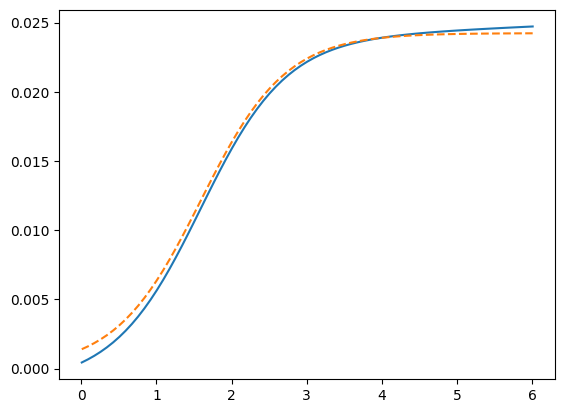

In [141]:
plotSigmoidFit(data_samples[data_samples.Well == plot_inds[2]], fit_data, fit_function=_sigmoid_drift)
plotSigmoidFit(data_samples[data_samples.Well == plot_inds[2]], fit_data, fit_function=_sigmoid)

In [142]:
data_plot = data_samples[data_samples.Well.isin(plot_inds)].copy()

In [143]:
endpoints = data_plot.groupby('Well').data_normalized.apply(lambda x: np.mean(x[-3:]))

In [144]:
data_plot = data_plot.merge(endpoints, on='Well')

In [145]:
data_plot['normalized_to_endpoint'] = data_plot.data_normalized_x/data_plot.data_normalized_y
data_plot = data_plot.rename({'data_normalized_y':'endpoint'},axis=1).rename({'data_normalized_x':'data_normalized'},axis=1)

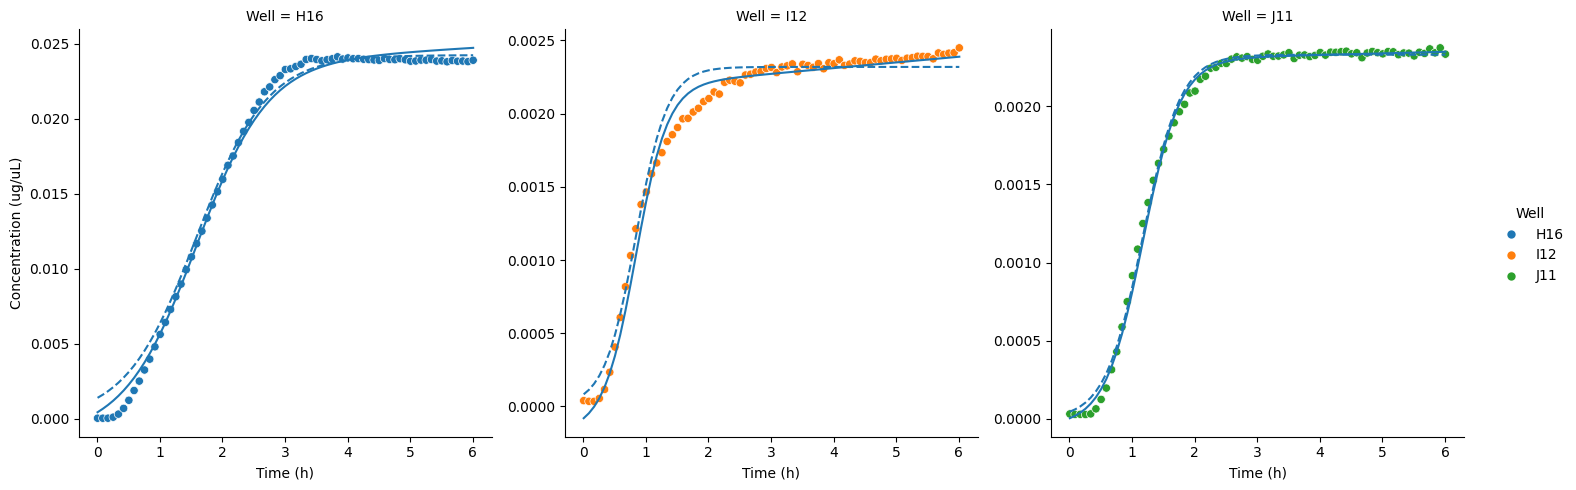

In [171]:
g = sns.relplot(data_plot,x ='hours',y='data_normalized', hue='Well', col='Well',
                facet_kws = {'sharey':False})
g.set_axis_labels('Time (h)', 'Concentration (ug/uL)')
g.map_dataframe(lambda data, color: plotSigmoidFit(data, fit_data, color, fit_function= _sigmoid_drift))
g.map_dataframe(lambda data, color: plotSigmoidFit(data, fit_data, color, fit_function= _sigmoid))

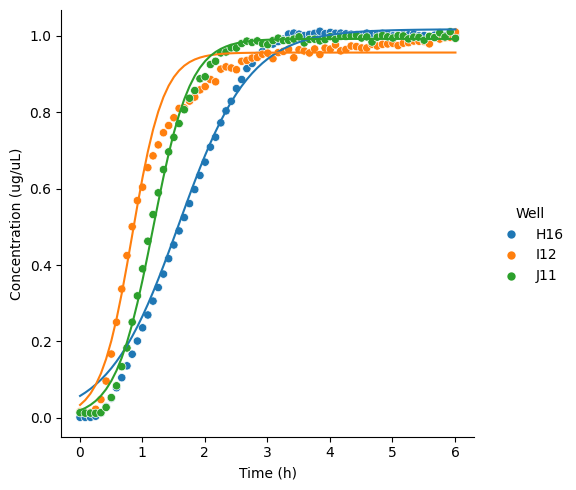

In [184]:
g = sns.relplot(data_plot,x ='hours',y='normalized_to_endpoint', hue='Well',
                facet_kws = {'sharey':False})
g.set_axis_labels('Time (h)', 'Concentration (ug/uL)')
g.map_dataframe(lambda data, color: plotSigmoidFit(data, fit_data, fit_function= _sigmoid_drift, normalized=True))
# g.map_dataframe(lambda data, color: plotSigmoidFit(data, fit_data, color, fit_function= _sigmoid))